# 03 — Entrenamiento del detector de anomalías

**Objetivo**: entrenar el modelo que aprende el comportamiento "normal" de cada bloque del día y
marca los anómalos, y con él rellenar las tres columnas que le faltan a `ResumenDatosML`:
`EXPECTED_VALUE`, `ANOMALY_SCORE` e `IS_ANOMALY`.

```
resumen_bloques.parquet (features del nb02) ──▶ baseline z-score
                                            └──▶ Isolation Forest ──▶ ResumenDatosML completa + modelo
```

Detectamos **dos familias de anomalías** (README del proyecto), y cada una tiene su señal en las
features que ya construimos:

| Familia | Ejemplo | Feature que la delata |
|---|---|---|
| **Ambiental** | nivel de O₃ inusualmente alto para un julio | `Z_SCORE` (lejos del valor esperado) |
| **Operativa — sensor caído** | faltan horas del bloque | `COBERTURA` baja |
| **Operativa — sensor congelado** | valor plano toda la franja | variabilidad relativa `CV` ≈ 0 |

> Alcance: aquí usamos un **baseline estadístico** + **Isolation Forest** (scikit-learn), que es
> simple, interpretable y no necesita GPU. El **LSTM Autoencoder** temporal que menciona el plan
> queda como siguiente paso (nb04): aprende secuencias hora a hora y capta anomalías de *forma*,
> pero requiere PyTorch y ventanas temporales.

## 0. Configuración

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import joblib
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Mismo estilo visual que los notebooks 01 y 02
mpl.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e0e0e0", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "lines.linewidth": 2,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "figure.dpi": 110,
})

RUTA_FEATURES = Path("../data/processed/resumen_bloques.parquet")   # entrada (nb02)
RUTA_SALIDA   = Path("../data/processed/resumen_datos_ml.parquet")  # ResumenDatosML completa
RUTA_MODELOS  = Path("../models/isolation_forest.joblib")           # modelos entrenados

MAGNITUDES = {7: "NO", 8: "NO2", 9: "PM2.5", 10: "PM10", 12: "NOx", 14: "O3"}
PALETA = {
    "NO2": "#0072B2", "NO": "#56B4E9", "NOx": "#CC79A7",
    "O3": "#009E73", "PM10": "#E69F00", "PM2.5": "#D55E00",
}
ORDEN = ["NO2", "NO", "NOx", "O3", "PM10", "PM2.5"]
print("Configuración lista.")

Configuración lista.


## 1. Cargar las features

Partimos de la tabla de bloques del nb02: una fila por (estación, magnitud, día, bloque) con sus
estadísticos, el valor esperado histórico (`MEDIA_ESPERADA`) y el `Z_SCORE`.

In [2]:
df = pd.read_parquet(RUTA_FEATURES)
print(f"{len(df):,} bloques × {df.shape[1]} columnas")
print("Rango temporal:", df.FECHA.min().date(), "→", df.FECHA.max().date())
df.head(3)

1,274,644 bloques × 24 columnas
Rango temporal: 2018-01-01 → 2026-04-30


,ESTACION,MAGNITUD,CONTAMINANTE,FECHA,BLOQUE,HORA_INICIO,HORA_FIN,ANO,MES,DIA_SEMANA,...,MAXIMO,HORA_MAXIMO,MINIMO,HORA_MINIMO,STD,RANGO,MEDIA_ESPERADA,STD_ESPERADA,DESVIACION,Z_SCORE
0,4,7,NO,2018-01-01,madrugada,0,6,2018,1,0,...,2.0,0,1.0,1,0.377964,1.0,21.179634,24.498469,-20.036777,-0.817879
1,4,7,NO,2018-01-01,manana,7,12,2018,1,0,...,4.0,9,1.0,7,1.169045,3.0,60.567704,67.004076,-58.734370,-0.876579
2,4,7,NO,2018-01-01,tarde,13,19,2018,1,0,...,4.0,19,1.0,13,1.112697,3.0,26.210693,38.828636,-24.496407,-0.630885


## 2. Detector baseline: regla del z-score

Antes de un modelo, el detector más simple posible: marcar como anómalo todo bloque cuyo nivel se
aleje más de **3 desviaciones típicas** de su valor esperado (`|Z_SCORE| > 3`). Es la regla
estadística clásica y nos sirve de **referencia** para juzgar si el modelo aporta algo.

In [3]:
UMBRAL_Z = 3.0
df["IS_ANOMALY_Z"] = df["Z_SCORE"].abs() > UMBRAL_Z

tasa = df.groupby("CONTAMINANTE")["IS_ANOMALY_Z"].mean().reindex(ORDEN) * 100
print(f"Bloques marcados por el baseline z-score: {df['IS_ANOMALY_Z'].mean()*100:.2f}% del total\n")
print("% de bloques anómalos por contaminante:")
print(tasa.round(2).to_string())

Bloques marcados por el baseline z-score: 1.35% del total

% de bloques anómalos por contaminante:
CONTAMINANTE
NO2      0.87
NO       2.06
NOx      1.66
O3       0.17
PM10     1.52
PM2.5    1.51


## 3. Modelo principal: Isolation Forest

El z-score solo mira el nivel. Queremos un detector que combine **las tres señales a la vez**
(nivel inusual, falta de datos y sensor congelado). El **Isolation Forest** es ideal: es *no
supervisado* (no necesitamos etiquetas de "anomalía", que no tenemos) y aísla los puntos raros
con pocos cortes aleatorios.

Le damos tres features **comparables entre estaciones** (clave, porque una estación de tráfico y
una de fondo tienen niveles muy distintos):

- `Z_SCORE` — cuán lejos del nivel esperado (anomalía **ambiental**).
- `COBERTURA` — fracción de horas medidas del bloque (anomalía **operativa**: sensor caído).
- `CV = STD / (|MEDIA| + 1)` — variabilidad relativa dentro del bloque; ≈ 0 indica **sensor
  congelado**. Es un ratio, así que no depende de la escala del contaminante.

Entrenamos **un modelo por contaminante** (como concluía el EDA), estandarizando las features.

In [4]:
# Features del modelo (robustas a la escala de cada estación/contaminante)
df["CV"] = df["STD"].fillna(0.0) / (df["MEDIA"].abs() + 1.0)
df["Z_SCORE"] = df["Z_SCORE"].fillna(0.0)   # NaN cuando el histórico no tenía dispersión
FEATURES = ["Z_SCORE", "COBERTURA", "CV"]

CONTAMINACION = 0.01   # esperamos ~1% de bloques anómalos (es el umbral, se puede ajustar)

df["ANOMALY_SCORE"] = np.nan
df["IS_ANOMALY"] = False
modelos, scalers = {}, {}

for mag, nombre in MAGNITUDES.items():
    mask = df["MAGNITUD"] == mag
    X = df.loc[mask, FEATURES].to_numpy()

    scaler = StandardScaler().fit(X)
    Xs = scaler.transform(X)

    iforest = IsolationForest(
        n_estimators=200, contamination=CONTAMINACION,
        random_state=0, n_jobs=-1,
    ).fit(Xs)

    # score_samples: cuanto más bajo, más anómalo -> lo negamos para que ALTO = MÁS ANÓMALO
    df.loc[mask, "ANOMALY_SCORE"] = -iforest.score_samples(Xs)
    df.loc[mask, "IS_ANOMALY"]    = iforest.predict(Xs) == -1

    modelos[nombre], scalers[nombre] = iforest, scaler

print(f"Entrenados {len(modelos)} modelos (uno por contaminante).")
print(f"Bloques marcados por Isolation Forest: {df['IS_ANOMALY'].mean()*100:.2f}% del total")

Entrenados 6 modelos (uno por contaminante).
Bloques marcados por Isolation Forest: 1.00% del total


## 4. ¿Tiene sentido lo que marca? (evaluación sin etiquetas)

No hay una "verdad" de anomalías etiquetada, así que evaluamos de tres formas: (1) mirando los
bloques más anómalos, (2) viendo cuánto se solapan modelo y baseline, y (3) sobre una serie
temporal concreta.

In [5]:
# (1) Los 8 bloques más anómalos según el modelo: deberían tener z extremo, cobertura baja o CV~0
cols = ["CONTAMINANTE", "ESTACION", "FECHA", "BLOQUE", "MEDIA", "MEDIA_ESPERADA",
        "Z_SCORE", "COBERTURA", "CV", "ANOMALY_SCORE"]
top = df.sort_values("ANOMALY_SCORE", ascending=False)[cols].head(8).copy()
top["FECHA"] = top["FECHA"].dt.date
top.round(2)

,CONTAMINANTE,ESTACION,FECHA,BLOQUE,MEDIA,MEDIA_ESPERADA,Z_SCORE,COBERTURA,CV,ANOMALY_SCORE
265765,PM10,18,2019-01-01,madrugada,129.50,14.88,8.82,0.57,1.38,0.82
378258,NO,27,2022-07-16,tarde,4.00,1.24,6.84,0.14,0.00,0.82
265769,PM10,18,2019-01-02,manana,134.00,19.01,8.56,0.17,0.00,0.80
559217,PM10,38,2023-04-10,manana,137.00,16.44,9.32,0.17,0.00,0.80
270627,PM10,18,2022-05-14,manana,138.00,18.54,9.41,0.17,0.00,0.80
1062581,NO,57,2019-08-14,tarde,5.00,1.55,4.51,0.14,0.00,0.80
700286,PM2.5,47,2020-05-23,manana,21.33,6.82,3.76,0.50,1.58,0.80
710329,PM10,47,2019-01-24,manana,110.00,16.69,7.57,0.17,0.00,0.80


In [6]:
# (2) Solapamiento entre el modelo (IF) y el baseline (z-score)
cruce = pd.crosstab(df["IS_ANOMALY"], df["IS_ANOMALY_Z"],
                    rownames=["IsolationForest"], colnames=["z-score |z|>3"])
print(cruce)
solo_if = ((df["IS_ANOMALY"]) & (~df["IS_ANOMALY_Z"])).sum()
print(f"\nBloques que SOLO detecta el modelo (no el z-score): {solo_if:,}")
print("→ son los que el z-score se pierde: caídas de sensor y valores congelados,")
print("  que el modelo capta gracias a COBERTURA y CV.")

z-score |z|>3      False  True 
IsolationForest                
False            1246843  15053
True               10550   2198

Bloques que SOLO detecta el modelo (no el z-score): 10,550
→ son los que el z-score se pierde: caídas de sensor y valores congelados,
  que el modelo capta gracias a COBERTURA y CV.


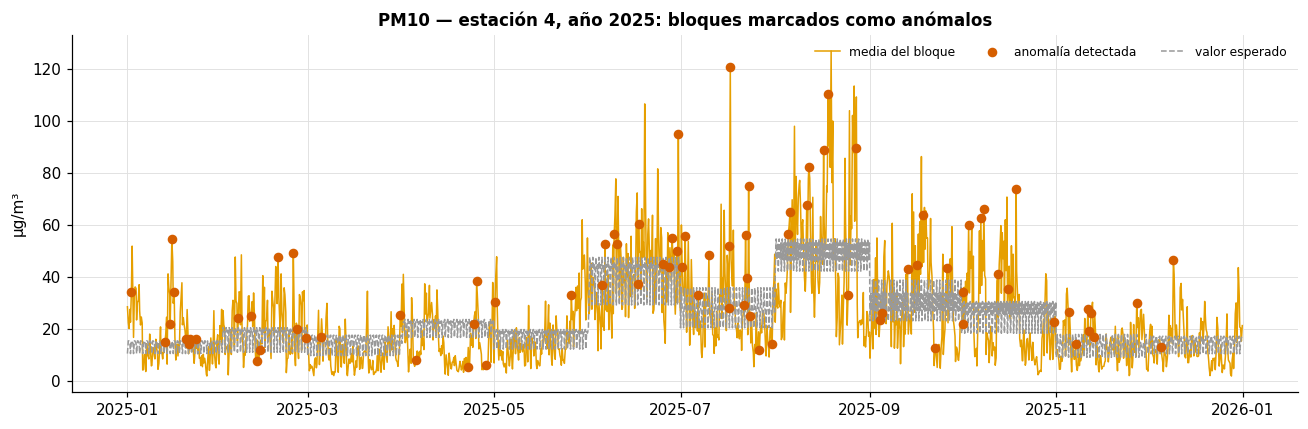

In [7]:
# (3) Serie temporal de ejemplo: la (estación, contaminante, año) con más anomalías
sel = df[df["IS_ANOMALY"]].groupby(["ESTACION", "CONTAMINANTE", "ANO"]).size().idxmax()
est_e, cont_e, ano_e = sel
ej = df[(df.ESTACION == est_e) & (df.CONTAMINANTE == cont_e) & (df.ANO == ano_e)].copy()
ej["TS"] = pd.to_datetime(ej["FECHA"]) + pd.to_timedelta(ej["HORA_INICIO"], unit="h")
ej = ej.sort_values("TS")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ej["TS"], ej["MEDIA"], color=PALETA[cont_e], linewidth=1, label="media del bloque")
anom = ej[ej["IS_ANOMALY"]]
ax.scatter(anom["TS"], anom["MEDIA"], color="#D55E00", s=28, zorder=3, label="anomalía detectada")
ax.plot(ej["TS"], ej["MEDIA_ESPERADA"], color="#999999", linewidth=1, linestyle="--", label="valor esperado")
ax.set_title(f"{cont_e} — estación {est_e}, año {ano_e}: bloques marcados como anómalos")
ax.set_ylabel("µg/m³"); ax.legend(loc="upper right", frameon=False, fontsize=8, ncols=3)
plt.tight_layout(); plt.show()

## 5. Ensamblar `ResumenDatosML` y guardar

Añadimos las tres columnas del modelo a la tabla y la guardamos. Con esto `ResumenDatosML` queda
**completa**: identificación + calendario + estadísticos + baseline + salida del detector.

- `EXPECTED_VALUE` = `MEDIA_ESPERADA` (el valor que el sistema esperaba para ese bloque).
- `ANOMALY_SCORE` = puntuación continua del Isolation Forest (**alto = más anómalo**).
- `IS_ANOMALY` = flag binario del modelo.

Guardamos también los modelos entrenados (`joblib`) para reutilizarlos en la inferencia en tiempo
real sin reentrenar.

In [8]:
df["EXPECTED_VALUE"] = df["MEDIA_ESPERADA"]

COLUMNAS = [
    # identificación
    "ESTACION", "MAGNITUD", "CONTAMINANTE", "FECHA", "BLOQUE", "HORA_INICIO", "HORA_FIN",
    # calendario
    "ANO", "MES", "DIA_SEMANA", "ES_FIN_SEMANA",
    # estadísticos del bloque
    "N_HORAS", "COBERTURA", "MEDIA", "MAXIMO", "HORA_MAXIMO", "MINIMO", "HORA_MINIMO", "STD", "RANGO",
    # baseline histórico
    "MEDIA_ESPERADA", "STD_ESPERADA", "DESVIACION", "Z_SCORE",
    # salida del modelo
    "EXPECTED_VALUE", "ANOMALY_SCORE", "IS_ANOMALY",
]
resumen_ml = (df[COLUMNAS]
              .sort_values(["ESTACION", "MAGNITUD", "FECHA", "HORA_INICIO"])
              .reset_index(drop=True))

RUTA_SALIDA.parent.mkdir(parents=True, exist_ok=True)
resumen_ml.to_parquet(RUTA_SALIDA, index=False)

RUTA_MODELOS.parent.mkdir(parents=True, exist_ok=True)
joblib.dump({"modelos": modelos, "scalers": scalers,
             "features": FEATURES, "contaminacion": CONTAMINACION}, RUTA_MODELOS)

print(f"Tabla guardada en {RUTA_SALIDA}  ({len(resumen_ml):,} filas × {resumen_ml.shape[1]} columnas)")
print(f"Modelos guardados en {RUTA_MODELOS}")
resumen_ml.head()

Tabla guardada en ..\data\processed\resumen_datos_ml.parquet  (1,274,644 filas × 27 columnas)
Modelos guardados en ..\models\isolation_forest.joblib


,ESTACION,MAGNITUD,CONTAMINANTE,FECHA,BLOQUE,HORA_INICIO,HORA_FIN,ANO,MES,DIA_SEMANA,...,HORA_MINIMO,STD,RANGO,MEDIA_ESPERADA,STD_ESPERADA,DESVIACION,Z_SCORE,EXPECTED_VALUE,ANOMALY_SCORE,IS_ANOMALY
0,4,7,NO,2018-01-01,madrugada,0,6,2018,1,0,...,1,0.377964,1.0,21.179634,24.498469,-20.036777,-0.817879,21.179634,0.391994,False
1,4,7,NO,2018-01-01,manana,7,12,2018,1,0,...,7,1.169045,3.0,60.567704,67.004076,-58.734370,-0.876579,60.567704,0.402981,False
2,4,7,NO,2018-01-01,tarde,13,19,2018,1,0,...,13,1.112697,3.0,26.210693,38.828636,-24.496407,-0.630885,26.210693,0.372655,False
3,4,7,NO,2018-01-01,noche,20,23,2018,1,0,...,23,0.816497,2.0,52.578475,68.449561,-50.578475,-0.738916,52.578475,0.374960,False
4,4,7,NO,2018-01-02,madrugada,0,6,2018,1,1,...,0,0.000000,0.0,21.179634,24.498469,-20.179634,-0.823710,21.179634,0.408980,False


## Conclusiones

1. **Baseline z-score**: regla simple (`|z| > 3`) que detecta niveles inusuales; sirve de
   referencia pero es ciega a los fallos de sensor.
2. **Isolation Forest por contaminante**: combina nivel (`Z_SCORE`), ausencia de datos
   (`COBERTURA`) y sensor congelado (`CV`) en features comparables entre estaciones. Detecta lo
   que el z-score se pierde (anomalías operativas).
3. **`ResumenDatosML` completa**: `data/processed/resumen_datos_ml.parquet`, ya con
   `EXPECTED_VALUE`, `ANOMALY_SCORE` e `IS_ANOMALY` — la tabla que consultará el chatbot.
4. **Modelos persistidos**: `models/isolation_forest.joblib`, listos para la inferencia en tiempo
   real sobre los datos que llegan de la API.